# E_S1 — Atom-Level Scatterplot Generation

Generate synthetic scatter plots for **6 atomic shape classes**:
linear, convex, concave, inflected, u_shape, spike.

Each atom has 2 families (positive/negative direction) × 3 parameter variants × 200 SNR levels × 20 replicates.

This data feeds the Random Forest atom classifier (E_S2).

In [12]:
from __future__ import annotations

import json
import math
import time
import os
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

OUTPUT_DIR = Path('output/S1')

In [13]:
N_PER_CASE = 500
N_REPLICATES = 20
SIGNAL_VARIANCE_GRID_SIZE = 20_001

# Dense SNR grid: 200 log-spaced from 0.001 to 500 + inf
SNR_GRID = sorted(np.geomspace(0.001, 500, 200).tolist()) + [math.inf]

# ═══════════════════════════════════════════
#  SWITCHES — toggle atom class granularity
# ═══════════════════════════════════════════
SPLIT_INFLECTED  = False  # True → s_curve + threshold; False → single inflected
ADD_SATURATION   = False  # True → add saturation atom (1 - exp(-kx))
ADD_MULTI_BRANCH = True   # True → add two_lines (F23) and line_parab (F24) atoms

# Build atom mapping based on switches
FAMILY_TO_ATOM = {
    "F01": "linear",    "F02": "linear",
    "F03": "convex",    "F06": "convex",
    "F04": "concave",   "F05": "concave",
    "F17": "u_shape",   "F18": "u_shape",
    "F19": "spike",     "F20": "spike",
}

if SPLIT_INFLECTED:
    FAMILY_TO_ATOM.update({"F13": "s_curve", "F14": "s_curve",
                           "F15": "threshold", "F16": "threshold"})
else:
    FAMILY_TO_ATOM.update({"F13": "inflected", "F14": "inflected",
                           "F15": "inflected", "F16": "inflected"})

if ADD_SATURATION:
    FAMILY_TO_ATOM.update({"F21": "saturation", "F22": "saturation"})

if ADD_MULTI_BRANCH:
    FAMILY_TO_ATOM.update({"F23": "two_lines", "F24": "line_parab"})

ATOM_CLASSES = sorted(set(FAMILY_TO_ATOM.values()))

# Human-annotated visibility boundaries
CLEAR_SNR = {
    'F01': 2.0, 'F02': 2.0,
    'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
    'F13': 15.0, 'F14': 15.0,
    'F15': 2.0, 'F16': 2.0,
    'F17': 1.0, 'F18': 1.0,
    'F19': 1.0, 'F20': 1.0,
    'F21': 2.0, 'F22': 2.0,
    'F23': 12.0, 'F24': 12.0,
}

THRESHOLD_SNR = {
    'F01': 0.3, 'F02': 0.3,
    'F03': 0.3, 'F04': 0.3, 'F05': 0.3, 'F06': 0.3,
    'F13': 7.0, 'F14': 7.0,
    'F15': 0.5, 'F16': 0.5,
    'F17': 0.3, 'F18': 0.3,
    'F19': 0.1, 'F20': 0.1,
    'F21': 0.3, 'F22': 0.3,
    'F23': 3.0, 'F24': 3.0,
}

FAMILIES_USED = sorted(FAMILY_TO_ATOM.keys())

print(f'── Config ──')
print(f'SPLIT_INFLECTED  = {SPLIT_INFLECTED}')
print(f'ADD_SATURATION   = {ADD_SATURATION}')
print(f'ADD_MULTI_BRANCH = {ADD_MULTI_BRANCH}')
print(f'Atom classes ({len(ATOM_CLASSES)}): {ATOM_CLASSES}')
print(f'Families: {len(FAMILIES_USED)}')
print(f'Replicates: {N_REPLICATES}')
print(f'SNR levels: {len(SNR_GRID)}')

── Config ──
SPLIT_INFLECTED  = False
ADD_SATURATION   = False
ADD_MULTI_BRANCH = True
Atom classes (8): ['concave', 'convex', 'inflected', 'line_parab', 'linear', 'spike', 'two_lines', 'u_shape']
Families: 16
Replicates: 20
SNR levels: 201


In [14]:
FAMILY_LABELS = {
    'F01': {'family_name': 'Linear positive', 'direction': 'positive', 'curvature': 'N/A'},
    'F02': {'family_name': 'Linear negative', 'direction': 'negative', 'curvature': 'N/A'},
    'F03': {'family_name': 'Power convex positive', 'direction': 'positive', 'curvature': 'convex'},
    'F04': {'family_name': 'Power convex negative', 'direction': 'negative', 'curvature': 'concave'},
    'F05': {'family_name': 'Power concave positive', 'direction': 'positive', 'curvature': 'concave'},
    'F06': {'family_name': 'Power concave negative', 'direction': 'negative', 'curvature': 'convex'},
    'F13': {'family_name': 'S-curve positive', 'direction': 'positive', 'curvature': 'inflected'},
    'F14': {'family_name': 'S-curve negative', 'direction': 'negative', 'curvature': 'inflected'},
    'F15': {'family_name': 'Threshold positive', 'direction': 'positive', 'curvature': 'inflected'},
    'F16': {'family_name': 'Threshold negative', 'direction': 'negative', 'curvature': 'inflected'},
    'F17': {'family_name': 'Inverted-U', 'direction': 'symmetric', 'curvature': 'u_shape'},
    'F18': {'family_name': 'U-shape', 'direction': 'symmetric', 'curvature': 'u_shape'},
    'F19': {'family_name': 'Spike', 'direction': 'up', 'curvature': 'spike'},
    'F20': {'family_name': 'Inverted Spike', 'direction': 'down', 'curvature': 'spike'},
    'F21': {'family_name': 'Saturation positive', 'direction': 'positive', 'curvature': 'saturation'},
    'F22': {'family_name': 'Saturation negative', 'direction': 'negative', 'curvature': 'saturation'},
    'F23': {'family_name': 'Two Lines', 'direction': 'positive', 'curvature': 'N/A'},
    'F24': {'family_name': 'Line and Parabola', 'direction': 'none / local', 'curvature': 'mixed'},
}

## Shape Configurations

Each family has 3 parameter variants (mild / standard / strong) controlling
the strength of the shape feature.

In [15]:
@dataclass(frozen=True)
class ShapeConfig:
    shape_config_id: int
    family_id: str
    variant_name: str
    variant_level: str
    params: dict[str, Any]


def build_shape_configs() -> list[ShapeConfig]:
    configs: list[ShapeConfig] = []

    def add(family_id, variant_name, variant_level, **params):
        if family_id not in FAMILIES_USED:
            return
        configs.append(ShapeConfig(
            shape_config_id=len(configs) + 1,
            family_id=family_id,
            variant_name=variant_name,
            variant_level=variant_level,
            params=params,
        ))

    # ── F01/F02: Linear ──
    for slope_sign, fid in [(1, 'F01'), (-1, 'F02')]:
        add(fid, 'slope_0.3', 'mild',     slope=slope_sign * 0.3, intercept=0.0)
        add(fid, 'slope_1',   'standard',  slope=slope_sign * 1.0, intercept=0.0)
        add(fid, 'slope_3',   'strong',    slope=slope_sign * 3.0, intercept=0.0)

    # ── F03: Power convex positive (y = x^p, p > 1) ──
    add('F03', 'p_1.5', 'mild',     p=1.5)
    add('F03', 'p_2.5', 'standard', p=2.5)
    add('F03', 'p_4',   'strong',   p=4.0)

    # ── F04: Power convex negative (y = -x^p, p > 1 → concave) ──
    add('F04', 'p_1.5', 'mild',     p=1.5)
    add('F04', 'p_2.5', 'standard', p=2.5)
    add('F04', 'p_4',   'strong',   p=4.0)

    # ── F05: Power concave positive (y = x^p, 0 < p < 1) ──
    add('F05', 'p_0.7', 'mild',     p=0.7)
    add('F05', 'p_0.5', 'standard', p=0.5)
    add('F05', 'p_0.15','strong',   p=0.15)

    # ── F06: Power concave negative (y = -x^p, 0 < p < 1 → convex) ──
    add('F06', 'p_0.7', 'mild',     p=0.7)
    add('F06', 'p_0.5', 'standard', p=0.5)
    add('F06', 'p_0.15','strong',   p=0.15)

    # ── F13/F14: S-curve ──
    for fid in ['F13', 'F14']:
        add(fid, 'k_6',  'mild',     k=6.0,  c=0.5, L1=0.0, L2=1.0)
        add(fid, 'k_8',  'standard', k=8.0,  c=0.5, L1=0.0, L2=1.0)
        add(fid, 'k_15', 'strong',   k=15.0, c=0.5, L1=0.0, L2=1.0)

    # ── F15/F16: Threshold ──
    for fid in ['F15', 'F16']:
        add(fid, 'd_0.15', 'mild',     a=0.0, b=1.0, delta=0.15, c=0.5)
        add(fid, 'd_0.08', 'standard', a=0.0, b=1.0, delta=0.08, c=0.5)
        add(fid, 'd_0.02', 'strong',   a=0.0, b=1.0, delta=0.02, c=0.5)

    # ── F17: Inverted-U / F18: U-shape ──
    add('F17', 'a_1',  'mild',     a=1.0,  c=0.5, d=0.0)
    add('F17', 'a_4',  'standard', a=4.0,  c=0.5, d=0.0)
    add('F17', 'a_12', 'strong',   a=12.0, c=0.5, d=0.0)
    add('F18', 'a_1',  'mild',     a=1.0,  c=0.5, d=0.0)
    add('F18', 'a_4',  'standard', a=4.0,  c=0.5, d=0.0)
    add('F18', 'a_12', 'strong',   a=12.0, c=0.5, d=0.0)

    # ── F19: Spike / F20: Inverted Spike (Laplacian peak) ──
    add('F19', 'w_0.08', 'mild',     width=0.08, c=0.5)
    add('F19', 'w_0.03', 'standard', width=0.03, c=0.5)
    add('F19', 'w_0.01', 'strong',   width=0.01, c=0.5)
    add('F20', 'w_0.08', 'mild',     width=0.08, c=0.5)
    add('F20', 'w_0.03', 'standard', width=0.03, c=0.5)
    add('F20', 'w_0.01', 'strong',   width=0.01, c=0.5)

    # ── F21: Saturation positive / F22: Saturation negative ──
    add('F21', 'k_2',  'mild',     k=2.0)
    add('F21', 'k_5',  'standard', k=5.0)
    add('F21', 'k_12', 'strong',   k=12.0)
    add('F22', 'k_2',  'mild',     k=2.0)
    add('F22', 'k_5',  'standard', k=5.0)
    add('F22', 'k_12', 'strong',   k=12.0)

    # ── F23: Two Lines (vary slope gap) ──
    # 6 variants (no pos/neg counterpart) to match ~24k cases
    add('F23', 'gap_narrow_a',  'mild',     m1=0.8, b1=0.0, m2=1.2, b2=0.0)
    add('F23', 'gap_narrow_b',  'mild',     m1=0.7, b1=0.1, m2=1.5, b2=-0.1)
    add('F23', 'gap_medium_a',  'standard', m1=0.5, b1=0.0, m2=2.0, b2=0.0)
    add('F23', 'gap_medium_b',  'standard', m1=0.3, b1=0.1, m2=2.5, b2=-0.1)
    add('F23', 'gap_wide_a',    'strong',   m1=0.2, b1=0.0, m2=3.0, b2=0.0)
    add('F23', 'gap_wide_b',    'strong',   m1=0.1, b1=0.0, m2=4.0, b2=0.0)

    # ── F24: Line + Parabola (vary divergence) ──
    # 6 variants (no pos/neg counterpart) to match ~24k cases
    add('F24', 'close_a', 'mild',     m=1.5, b_line=0.0, a_para=0.8, h=0.5, peak=0.3)
    add('F24', 'close_b', 'mild',     m=1.0, b_line=0.1, a_para=1.0, h=0.5, peak=0.25)
    add('F24', 'mid_a',   'standard', m=2.5, b_line=0.0, a_para=1.6, h=0.5, peak=0.4)
    add('F24', 'mid_b',   'standard', m=2.0, b_line=0.0, a_para=2.0, h=0.5, peak=0.35)
    add('F24', 'far_a',   'strong',   m=3.5, b_line=0.0, a_para=3.0, h=0.5, peak=0.5)
    add('F24', 'far_b',   'strong',   m=3.0, b_line=0.0, a_para=4.0, h=0.5, peak=0.6)

    return configs


shape_configs = build_shape_configs()
print(f'Shape configs: {len(shape_configs)}')
for atom in ATOM_CLASSES:
    fids = sorted([f for f, a in FAMILY_TO_ATOM.items() if a == atom])
    n_cfg = sum(1 for c in shape_configs if c.family_id in fids)
    print(f'  {atom:<12s}: {n_cfg} configs ({", ".join(fids)})')

Shape configs: 54
  concave     : 6 configs (F04, F05)
  convex      : 6 configs (F03, F06)
  inflected   : 12 configs (F13, F14, F15, F16)
  line_parab  : 6 configs (F24)
  linear      : 6 configs (F01, F02)
  spike       : 6 configs (F19, F20)
  two_lines   : 6 configs (F23)
  u_shape     : 6 configs (F17, F18)


In [16]:
_NEGATIVE_COUNTERPART = {
    'F04': 'F03', 'F06': 'F05', 'F14': 'F13', 'F16': 'F15',
    'F20': 'F19', 'F22': 'F21',
}


def evaluate_signal(x, cfg, rng=None):
    x = np.asarray(x, dtype=float)
    p = cfg.params
    fid = cfg.family_id

    if fid in _NEGATIVE_COUNTERPART:
        pos_cfg = ShapeConfig(
            shape_config_id=cfg.shape_config_id,
            family_id=_NEGATIVE_COUNTERPART[fid],
            variant_name=cfg.variant_name,
            variant_level=cfg.variant_level,
            params=cfg.params,
        )
        return -evaluate_signal(x, pos_cfg, rng=rng)

    if fid in ('F01', 'F02'):
        return p['slope'] * x + p.get('intercept', 0.0)
    if fid in ('F03', 'F05'):
        return x ** p['p']
    if fid == 'F13':
        return p['L1'] + (p['L2'] - p['L1']) / (1.0 + np.exp(-p['k'] * (x - p['c'])))
    if fid == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['a'] + (p['b'] - p['a']) * t
    if fid == 'F17':
        return -p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F18':
        return p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F19':
        return np.exp(-np.abs(x - p['c']) / p['width'])
    if fid == 'F21':
        return 1.0 - np.exp(-p['k'] * x)

    # ── Multi-branch families ──
    if fid == 'F23':
        y0 = p['b1'] + p['m1'] * x
        y1 = p['b2'] + p['m2'] * x
        if rng is None:
            return 0.5 * (y0 + y1)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y0, y1)

    if fid == 'F24':
        y_line = p['b_line'] + p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return 0.5 * (y_line + y_para)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y_line, y_para)

    raise ValueError(f'Unknown family: {fid}')

In [17]:
_signal_variance_cache = {}

def signal_variance(cfg):
    if cfg.shape_config_id not in _signal_variance_cache:
        x_grid = np.linspace(0.0, 1.0, SIGNAL_VARIANCE_GRID_SIZE)
        rng = np.random.default_rng(cfg.shape_config_id)
        var = float(np.var(evaluate_signal(x_grid, cfg, rng=rng), ddof=0))
        _signal_variance_cache[cfg.shape_config_id] = max(var, 1e-30)
    return _signal_variance_cache[cfg.shape_config_id]


def sigma0_for_snr(cfg, snr):
    if math.isinf(snr):
        return 0.0
    return math.sqrt(signal_variance(cfg) / snr)


def sample_x(n, rng):
    return rng.uniform(0.0, 1.0, size=n)

## Build Case Metadata

Each case = one scatter plot configuration:
(family × variant × SNR × replicate)

In [18]:
def build_cases():
    rows = []
    cfg_map = {}

    for cfg in shape_configs:
        cfg_map[cfg.shape_config_id] = cfg
        labels = FAMILY_LABELS[cfg.family_id]
        atom = FAMILY_TO_ATOM[cfg.family_id]

        for snr in SNR_GRID:
            for rep in range(N_REPLICATES):
                rows.append({
                    'case_id': len(rows) + 1,
                    'shape_config_id': cfg.shape_config_id,
                    'family_id': cfg.family_id,
                    'family_name': labels['family_name'],
                    'atom_class': atom,
                    'variant_name': cfg.variant_name,
                    'variant_level': cfg.variant_level,
                    'params_json': json.dumps(cfg.params, sort_keys=True),
                    'snr': 'inf' if math.isinf(snr) else float(snr),
                    'replicate': rep,
                    'n': N_PER_CASE,
                    'direction': labels['direction'],
                })

    return pd.DataFrame(rows), cfg_map


cases_df, cfg_map = build_cases()

print(f'Total cases: {len(cases_df):,}')
print(f'\nPer atom class:')
print(cases_df.groupby('atom_class')['case_id'].count().to_string())
print(f'\nPer family:')
print(cases_df.groupby(['family_id', 'atom_class'])['case_id'].count().to_string())
print(f'\nVariant levels: {cases_df["variant_level"].unique().tolist()}')
print(f'Replicates: {cases_df["replicate"].nunique()}')
print(f'SNR levels: {cases_df["snr"].nunique()}')

Total cases: 217,080

Per atom class:
atom_class
concave       24120
convex        24120
inflected     48240
line_parab    24120
linear        24120
spike         24120
two_lines     24120
u_shape       24120

Per family:
family_id  atom_class
F01        linear        12060
F02        linear        12060
F03        convex        12060
F04        concave       12060
F05        concave       12060
F06        convex        12060
F13        inflected     12060
F14        inflected     12060
F15        inflected     12060
F16        inflected     12060
F17        u_shape       12060
F18        u_shape       12060
F19        spike         12060
F20        spike         12060
F23        two_lines     24120
F24        line_parab    24120

Variant levels: ['mild', 'standard', 'strong']
Replicates: 20
SNR levels: 201


## Generate Scatter Points

In [19]:
def generate_scatter_xy(case_row, cfg_map):
    cfg = cfg_map[int(case_row['shape_config_id'])]
    seed = int(case_row['case_id']) * 1000 + int(case_row['replicate'])
    rng = np.random.default_rng(seed)

    x = sample_x(N_PER_CASE, rng)
    y_signal = evaluate_signal(x, cfg, rng=rng)

    snr = math.inf if str(case_row['snr']) == 'inf' else float(case_row['snr'])
    sigma0 = sigma0_for_snr(cfg, snr)
    if sigma0 > 0:
        y = y_signal + rng.normal(0.0, sigma0, size=N_PER_CASE)
    else:
        y = y_signal.copy()

    return x.astype(np.float32), y.astype(np.float32)

## Export Dataset

In [20]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
n_total = len(cases_df)

cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
print(f'Saved cases.csv ({n_total:,} rows)')

x_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)
y_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)

t0 = time.time()
for idx in range(n_total):
    row = cases_df.iloc[idx]
    x_all[idx], y_all[idx] = generate_scatter_xy(row, cfg_map)
    if (idx + 1) % 20000 == 0:
        elapsed = time.time() - t0
        rate = (idx + 1) / elapsed
        eta = (n_total - idx - 1) / rate
        print(f'  {idx+1:>7,}/{n_total:,}  ({rate:.0f} cases/s, ETA {eta:.0f}s)')

np.savez_compressed(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)
elapsed = time.time() - t0
size_mb = (OUTPUT_DIR / 'scatter_points.npz').stat().st_size / 1e6
print(f'Saved scatter_points.npz  shape=({n_total:,}, {N_PER_CASE})  {size_mb:.1f} MB  ({elapsed:.0f}s)')

Saved cases.csv (217,080 rows)
   20,000/217,080  (16636 cases/s, ETA 12s)
   40,000/217,080  (18637 cases/s, ETA 10s)
   60,000/217,080  (18533 cases/s, ETA 8s)
   80,000/217,080  (18826 cases/s, ETA 7s)
  100,000/217,080  (18843 cases/s, ETA 6s)
  120,000/217,080  (18636 cases/s, ETA 5s)
  140,000/217,080  (18983 cases/s, ETA 4s)
  160,000/217,080  (19142 cases/s, ETA 3s)
  180,000/217,080  (19242 cases/s, ETA 2s)
  200,000/217,080  (19304 cases/s, ETA 1s)
Saved scatter_points.npz  shape=(217,080, 500)  788.1 MB  (41s)


## Verification

Preview scatter plots: 6 atoms × 3 variants at SNR=inf and SNR=5.

In [21]:
cases_df['snr_float'] = cases_df['snr'].apply(lambda x: math.inf if str(x) == 'inf' else float(x))

print(f'── Data Summary ──')
print(f'Total cases: {len(cases_df):,}')
print(f'Families: {len(cases_df["family_id"].unique())}')
print(f'Atom classes: {len(cases_df["atom_class"].unique())}')
print()

# Visibility zones
for fid in FAMILIES_USED:
    atom = FAMILY_TO_ATOM[fid]
    fam = cases_df[cases_df['family_id'] == fid]
    visible = len(fam[fam['snr_float'] >= CLEAR_SNR[fid]])
    fuzzy = len(fam[(fam['snr_float'] > THRESHOLD_SNR[fid]) & (fam['snr_float'] < CLEAR_SNR[fid])])
    invisible = len(fam[fam['snr_float'] <= THRESHOLD_SNR[fid]])
    print(f'{fid} ({atom:<10s}): visible={visible:>5,}  fuzzy={fuzzy:>4,}  invisible={invisible:>5,}')

── Data Summary ──
Total cases: 217,080
Families: 16
Atom classes: 8

F01 (linear    ): visible=5,100  fuzzy=1,740  invisible=5,220
F02 (linear    ): visible=5,100  fuzzy=1,740  invisible=5,220
F03 (convex    ): visible=5,100  fuzzy=1,740  invisible=5,220
F04 (concave   ): visible=5,100  fuzzy=1,740  invisible=5,220
F05 (concave   ): visible=5,100  fuzzy=1,740  invisible=5,220
F06 (convex    ): visible=5,100  fuzzy=1,740  invisible=5,220
F13 (inflected ): visible=3,300  fuzzy= 660  invisible=8,100
F14 (inflected ): visible=3,300  fuzzy= 660  invisible=8,100
F15 (inflected ): visible=5,100  fuzzy=1,260  invisible=5,700
F16 (inflected ): visible=5,100  fuzzy=1,260  invisible=5,700
F17 (u_shape   ): visible=5,760  fuzzy=1,080  invisible=5,220
F18 (u_shape   ): visible=5,760  fuzzy=1,080  invisible=5,220
F19 (spike     ): visible=5,760  fuzzy=2,100  invisible=4,200
F20 (spike     ): visible=5,760  fuzzy=2,100  invisible=4,200
F23 (two_lines ): visible=6,960  fuzzy=2,520  invisible=14,640
F

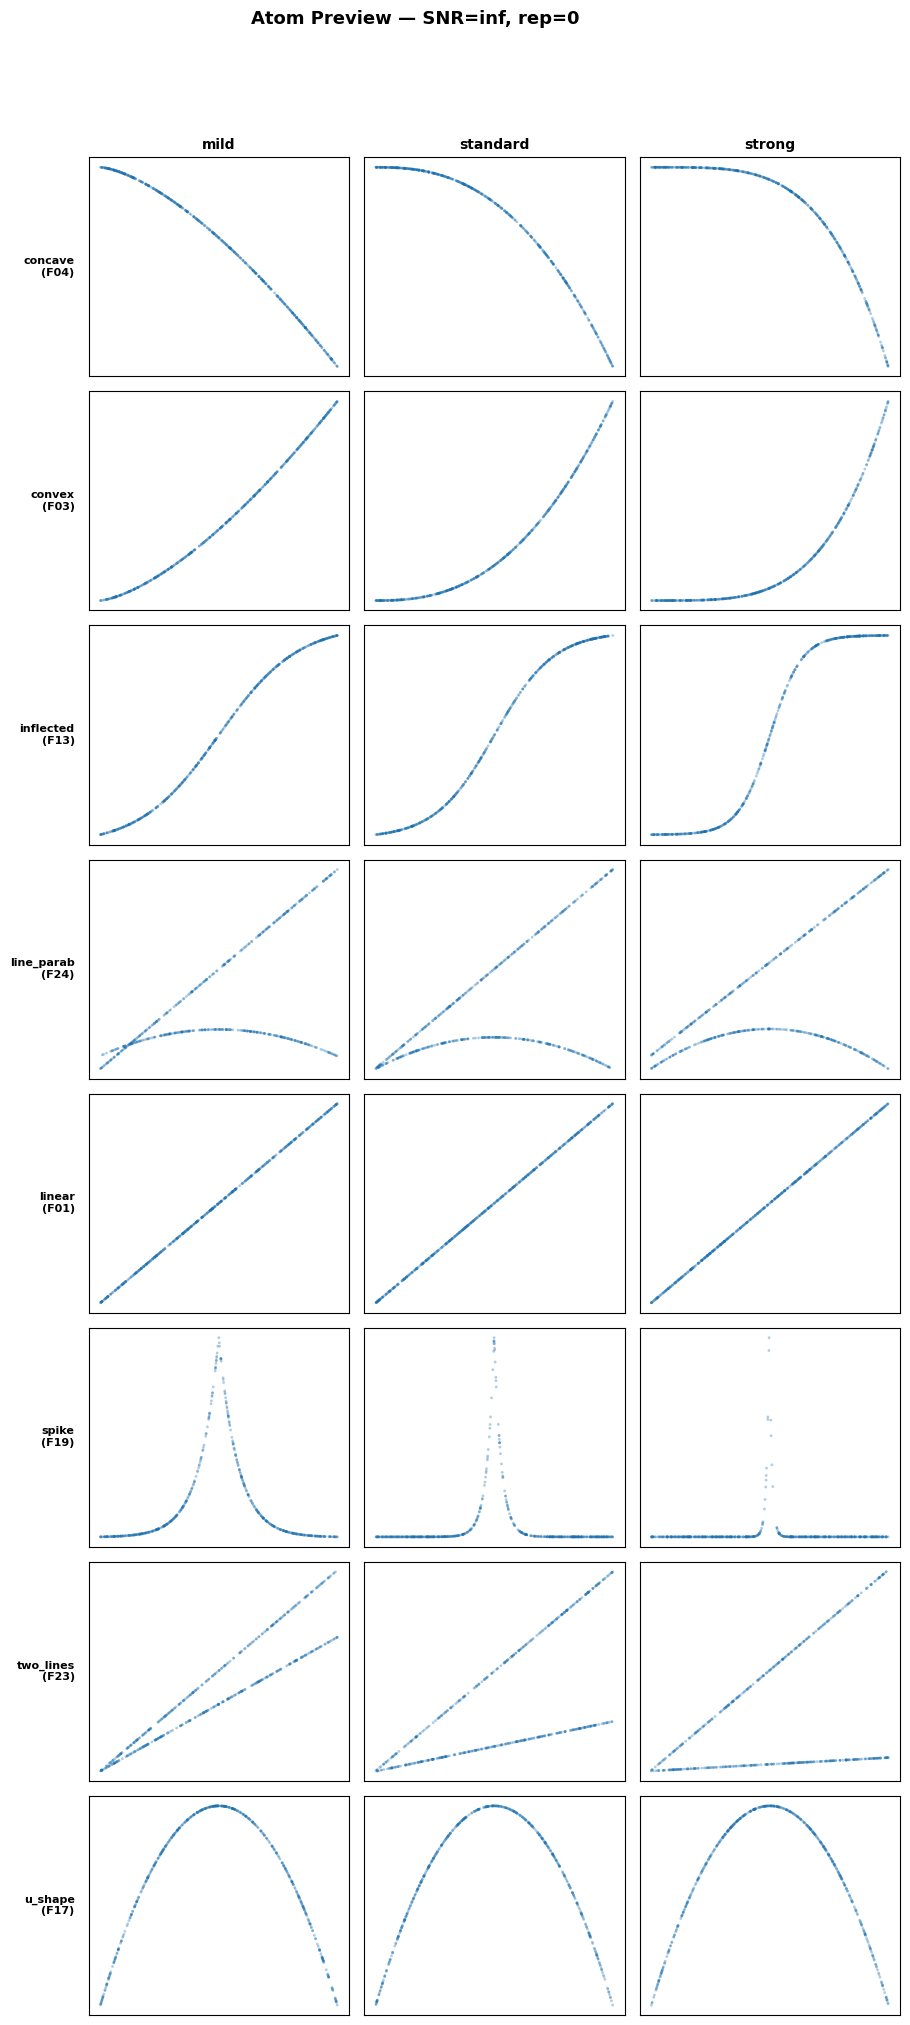

Saved preview_snr_inf.png


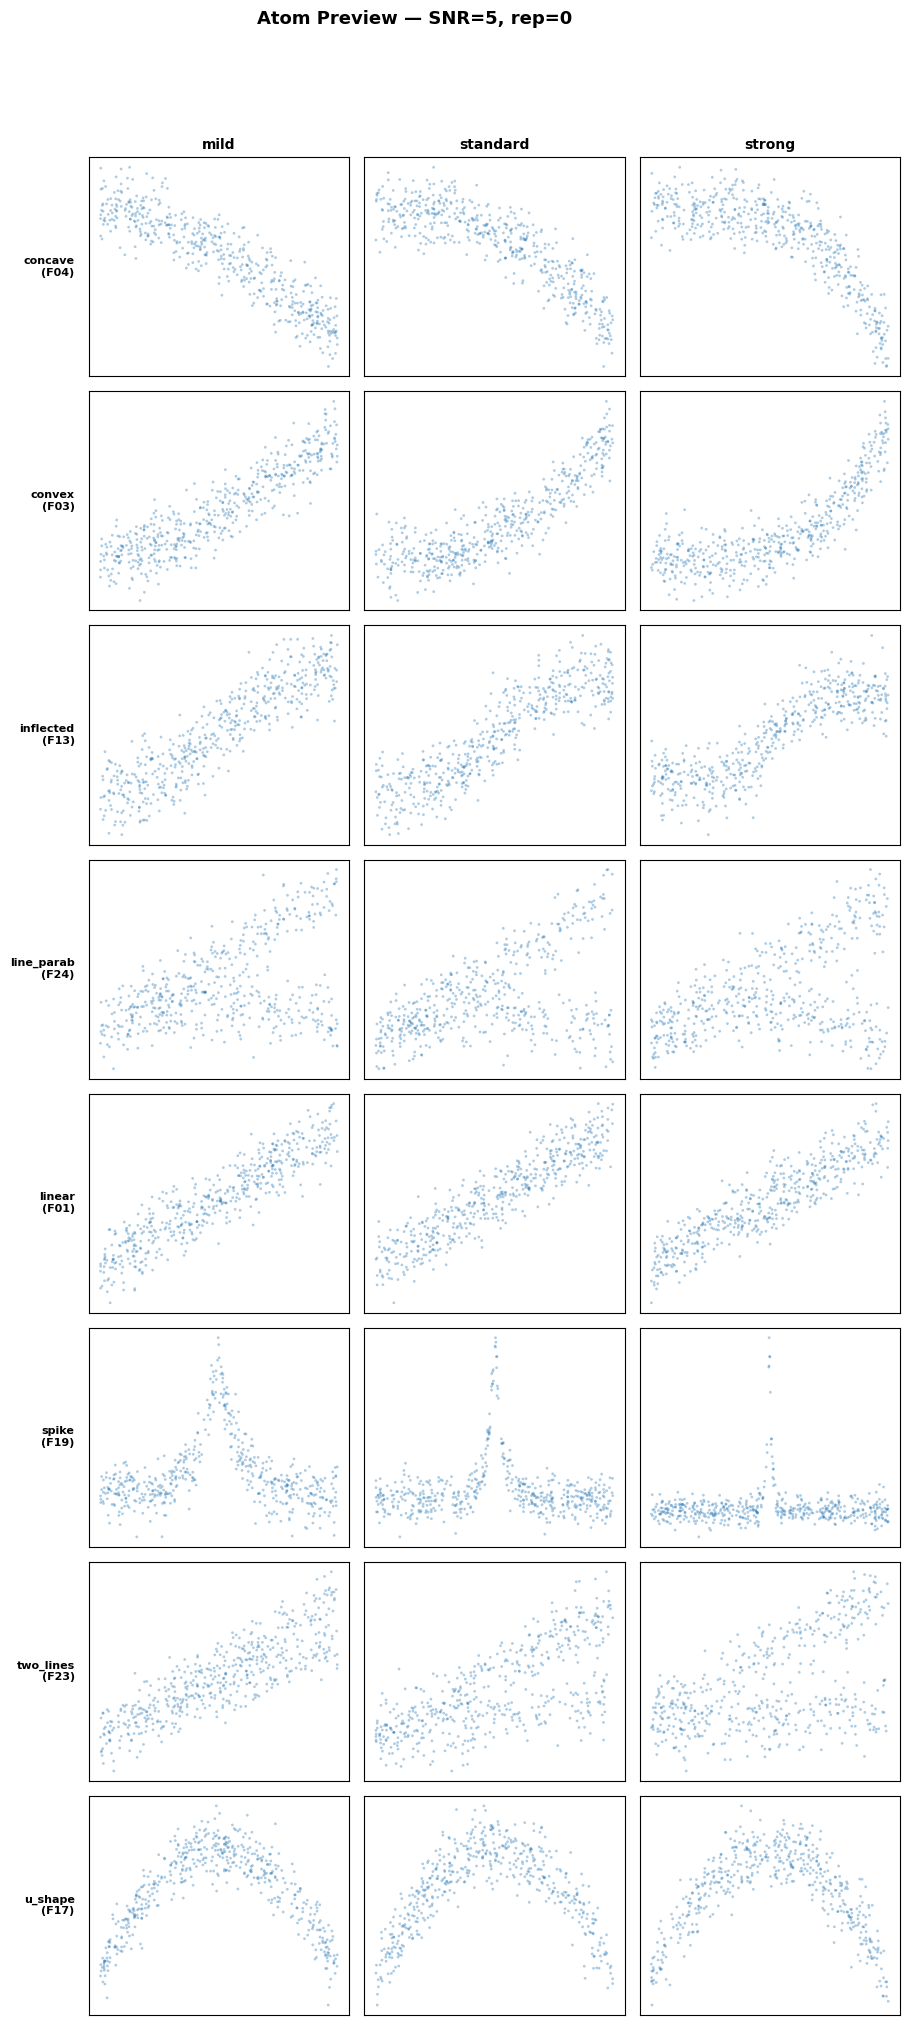

Saved preview_snr_5.png


In [22]:
# Preview: each atom × variant at clean (inf) and noisy (SNR=5)
case_idx_map = pd.Series(np.arange(len(cases_df)), index=cases_df['case_id']).to_dict()

for snr_target in [math.inf, 5.0]:
    snr_label = 'inf' if math.isinf(snr_target) else f'{snr_target:.0f}'

    fig, axes = plt.subplots(len(ATOM_CLASSES), 3, figsize=(10, 2.5 * len(ATOM_CLASSES)))
    fig.suptitle(f'Atom Preview — SNR={snr_label}, rep=0',
                 fontsize=13, fontweight='bold', y=1.01)

    for row_i, atom in enumerate(ATOM_CLASSES):
        fids = sorted([f for f, a in FAMILY_TO_ATOM.items() if a == atom])
        fid = fids[0]

        for col_i, vlevel in enumerate(['mild', 'standard', 'strong']):
            ax = axes[row_i, col_i]
            match = cases_df[
                (cases_df['family_id'] == fid) &
                (cases_df['variant_level'] == vlevel) &
                (cases_df['replicate'] == 0) &
                (cases_df['snr_float'] == snr_target if not math.isinf(snr_target)
                 else np.isinf(cases_df['snr_float']))
            ]
            if len(match) == 0:
                if math.isinf(snr_target):
                    match = cases_df[
                        (cases_df['family_id'] == fid) &
                        (cases_df['variant_level'] == vlevel) &
                        (cases_df['replicate'] == 0) &
                        (cases_df['snr'].astype(str) == 'inf')
                    ]
                else:
                    closest = cases_df[
                        (cases_df['family_id'] == fid) &
                        (cases_df['variant_level'] == vlevel) &
                        (cases_df['replicate'] == 0)
                    ]
                    closest = closest[np.isfinite(closest['snr_float'])]
                    if len(closest) > 0:
                        best_idx = (closest['snr_float'] - snr_target).abs().idxmin()
                        match = closest.loc[[best_idx]]

            if len(match) > 0:
                cid = int(match.iloc[0]['case_id'])
                idx = case_idx_map[cid]
                ax.scatter(x_all[idx], y_all[idx], s=4, alpha=0.35,
                           color='#1a6faf', edgecolors='none')

            if row_i == 0:
                ax.set_title(vlevel, fontsize=10, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(f'{atom}\n({fid})', fontsize=8, fontweight='bold',
                              rotation=0, ha='right', va='center', labelpad=10)
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0.08, 0, 1, 0.97])
    plt.savefig(OUTPUT_DIR / f'preview_snr_{snr_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved preview_snr_{snr_label}.png')